In [22]:
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import json

from scipy.ndimage.filters import gaussian_filter1d

In [23]:
def read_log(filename, key_str='train'):
    record = []
    with open(filename, 'rt') as f:
        for line in f.readlines():
            if not key_str in line:
                continue
            json_content = json.loads(line.split(']')[-1])
            try:
                record.append(
                    json_content
                )
            except:
                pass
    return record


filter_width = .1

In [24]:
rec = read_log(filename='log/output.log', key_str="train lower bound noisy")
data = defaultdict(list)
for i, this_record in enumerate(rec):
    for k in this_record:
        data[k].append(this_record[k])
    data['id'].append(i)
df = pd.DataFrame(data)
print(df.shape)

(6, 9)


In [25]:
df

,loss,pos_tv,pos_nll,neg_tv,neg_nll,tv,mle_loss,sigma,id
0,3.632924,0.147981,2.133447,0.660786,1.499476,0.962451,3.632924,3.000000,0
1,3.591646,0.149972,2.098617,0.661996,1.493030,0.964479,3.591646,2.997000,1
2,3.679860,0.140878,2.149877,0.676298,1.529983,0.981718,3.679860,2.994003,2
3,3.666237,0.144465,2.154224,0.675085,1.512012,0.983344,3.666237,2.991009,3
4,3.602844,0.148954,2.114346,0.673454,1.488498,0.984500,3.602844,2.988018,4
5,3.647504,0.138543,2.196155,0.662496,1.451349,0.967283,3.647504,2.985030,5


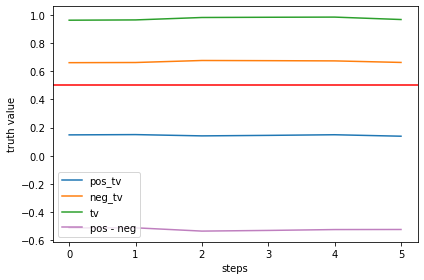

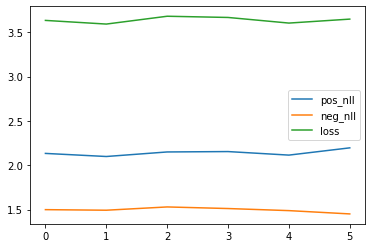

In [26]:

fig, ax1 = plt.subplots()

ax1.set_xlabel('steps')
ax1.set_ylabel('truth value')

keys = ['pos_tv', 'neg_tv', 'tv']
for label in keys:
    ax1.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
ax1.plot(df['id'], gaussian_filter1d(df['pos_tv'] - df['neg_tv'], filter_width), label='pos - neg', color='purple', alpha=0.5)
plt.axhline(y=0.5, color='r', linestyle='-')
ax1.legend()
# ax1.set_yscale('log')

# ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
# ax2.plot(df['id'], df['sigma'], color='pink')
# 
# ax2.set_ylabel('sigma')  # we already handled the x-label with ax1

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

keys = ['pos_nll', 'neg_nll', 'loss']
for label in keys:
    plt.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
# plt.yscale('log')
plt.legend()
plt.show()


In [27]:
rec = read_log(filename='log/output.log', key_str='evalueate train epoch')
data = defaultdict(list)
for i, this_record in enumerate(rec):
    for k in this_record:
        for k1 in this_record[k]:
            data[k+'_'+k1].append(this_record[k][k1])
    data['id'].append(i)
df = pd.DataFrame(data)
print(df.shape)

(0, 0)


KeyError: 'id'

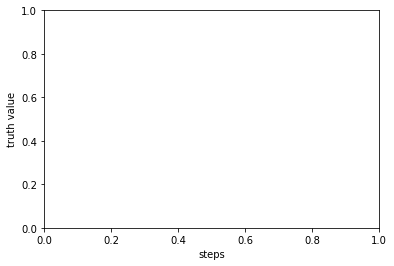

In [28]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('steps')
ax1.set_ylabel('truth value')

keys = ['1p_mrr','2i_mrr','1p_hit3', '2i_hit3']
for label in keys:
    ax1.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
ax1.legend()
# ax1.set_yscale('log')

# ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
# ax2.plot(df['id'], df['sigma'], color='pink')
# 
# ax2.set_ylabel('sigma')  # we already handled the x-label with ax1

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()
